In [69]:
import os
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Data Ingestion and EDA

In [70]:
data = yf.download("USDNGN=X", start="2015-01-01", end="2026-07-24")

[*********************100%***********************]  1 of 1 completed


In [71]:
data.columns = data.columns.droplevel(1)

In [72]:
data.sample(7)

Price,Close,High,Low,Open,Volume
Date,,,,,
2017-03-02,314.000000,315.000000,314.000000,314.500000,0
2026-07-17,1380.719971,1380.719971,1378.869995,1380.719971,0
2021-11-26,410.899994,411.049988,409.390015,410.899994,0
2025-12-08,1449.579956,1451.750000,1448.550049,1448.869995,0
2016-03-30,199.000000,199.000000,196.289993,196.289993,0
2022-08-31,422.380005,422.380005,421.380005,422.380005,0
2015-04-17,195.259995,198.899994,196.350006,196.350006,0


In [73]:
def fetch_forex_data(ticker="USDNGN=X", start_date="2015-01-01", end_date="2026-07-24"):
    """
    Fetches forex data from Yahoo Finance for a given ticker and date range.

    Parameters:
    ticker (str): The ticker symbol for the forex pair (default is "USDNGN=X").
    start_date (str): The start date for the data in "YYYY-MM-DD" format (default is "2015-01-01").
    end_date (str): The end date for the data in "YYYY-MM-DD" format (default is "2026-07-24").

    Returns:
    pd.DataFrame: A DataFrame containing the forex data.
    """
    print(f"Initializing data download for {ticker}...")
    print(f"Window: From {start_date} to {end_date}")

    data = yf.download(ticker, start=start_date, end=end_date)

    # Drop the multi-level column index
    data.columns = data.columns.droplevel(1)

    if data.empty:
        raise ValueError(
            f"No data retrieved for ticker {ticker}. Verify connection or ticker symbol.")

    missing_vals = data['Close'].isnull().sum()
    print(f"Missing values in 'Close' price: {missing_vals}")

    print(f"Successfully downloaded {len(data)} rows.")
    return data


def save_data(df, directory="../data/raw", filename="raw_usd_ngn.csv"):
    """
    Saves the dataframe to a local directory.
    """
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}/")

    filepath = os.path.join(directory, filename)
    df.to_csv(filepath)
    print(f"Data saved successfully to: {filepath}")


if __name__ == "__main__":
    try:
        # Fetch data from 2015 up to 24th of July 2026
        df_fx = fetch_forex_data(
            ticker="USDNGN=X",
            start_date="2015-01-01",
            end_date="2026-07-24"
        )

        df_fx.columns = df_fx.columns.droplevel(
            1)  # Drop the multi-level column index

        # Inspect the first few rows
        print("\nSnapshot of the data:")
        print(df_fx.head())

        # Save to disk
        save_data(df_fx)

    except Exception as e:
        print(f"An error occurred: {e}")

[*********************100%***********************]  1 of 1 completed

Initializing data download for USDNGN=X...
Window: From 2015-01-01 to 2026-07-24
Missing values in 'Close' price: 0
Successfully downloaded 3009 rows.
An error occurred: Too many levels: Index has only 1 level, not 2


In [74]:
fetch_forex_data()

[*********************100%***********************]  1 of 1 completed

Initializing data download for USDNGN=X...
Window: From 2015-01-01 to 2026-07-24
Missing values in 'Close' price: 0
Successfully downloaded 3009 rows.


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,182.300003,181.380005,181.380005,181.380005,0
2015-01-02,181.380005,182.899994,181.009995,181.869995,0
2015-01-05,182.699997,183.399994,181.500000,182.350006,0
2015-01-06,183.199997,181.949997,180.979996,180.979996,0
2015-01-07,183.600006,182.279999,181.350006,182.279999,0
...,...,...,...,...,...
2026-07-20,1379.140015,1380.359985,1378.270020,1379.140015,0
2026-07-21,1379.439941,1381.140015,1377.939941,1379.439941,0
2026-07-22,1379.910034,1380.250000,1372.579956,1379.660034,0


In [75]:
save_data(df_fx)

Data saved successfully to: ../data/raw\raw_usd_ngn.csv


In [76]:
df_fx

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,182.300003,181.380005,181.380005,181.380005,0
2015-01-02,181.380005,182.899994,181.009995,181.869995,0
2015-01-05,182.699997,183.399994,181.500000,182.350006,0
2015-01-06,183.199997,181.949997,180.979996,180.979996,0
2015-01-07,183.600006,182.279999,181.350006,182.279999,0
...,...,...,...,...,...
2026-07-20,1379.140015,1380.359985,1378.270020,1379.140015,0
2026-07-21,1379.439941,1381.140015,1377.939941,1379.439941,0
2026-07-22,1379.910034,1380.250000,1372.579956,1379.660034,0


In [77]:
df_fx.dtypes

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [78]:
df_fx.shape

(3009, 5)

In [79]:
df_fx.describe()

Price,Close,High,Low,Open,Volume
count,3009.000000,3009.000000,3009.000000,3009.000000,3009.0
mean,613.577075,617.642906,611.145493,614.300826,0.0
std,476.738631,478.362667,474.116468,476.264700,0.0
min,1.000000,180.419998,1.000000,175.669998,0.0
25%,355.000000,358.000000,355.000000,357.000000,0.0
50%,380.500000,385.410004,379.519989,380.700012,0.0
75%,771.539978,776.679993,765.000000,770.270020,0.0
max,1696.199951,1702.229980,1684.800049,1692.640015,0.0


In [80]:
df_fx.nunique()

Price
Close     1466
High      1636
Low       1630
Open      1691
Volume       1
dtype: int64

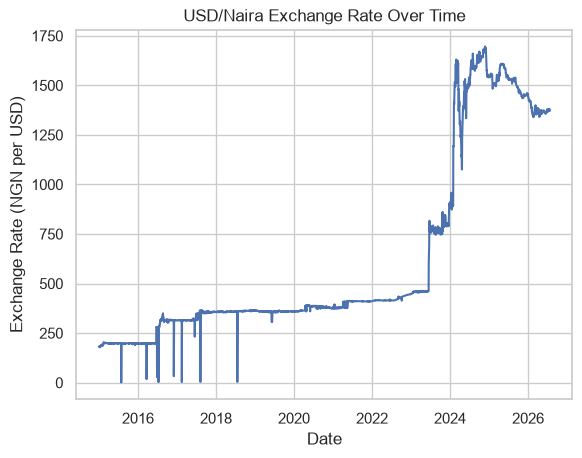

In [81]:
sns.set_theme(style="whitegrid")
sns.lineplot(data=df_fx, x=df_fx.index, y='Close')
plt.title("USD/Naira Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate (NGN per USD)")
plt.savefig("../reports/figures/(USD per Naira)_Exchange_Rate_Over_Time.png",
            dpi=300, bbox_inches="tight")
plt.show()

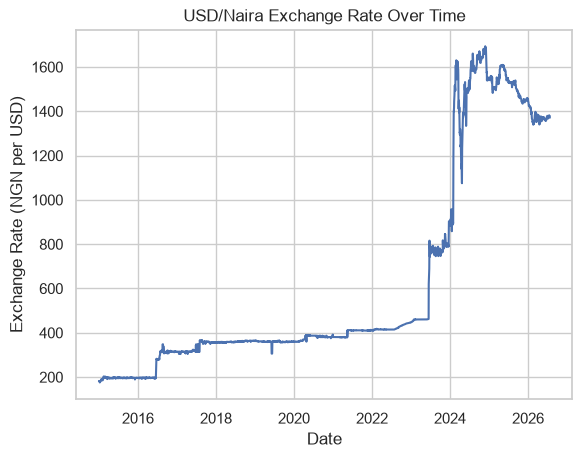

In [82]:
sns.set_theme(style="whitegrid")
sns.lineplot(data=df_fx, x=df_fx.index, y='Open')
plt.title("USD/Naira Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate (NGN per USD)")
# plt.savefig("../reports/figures/(USD per Naira)_Exchange_Rate_Over_Time.png",
# dpi=300, bbox_inches="tight")
plt.show()

--- Raw Close Price Stationarity ---

🔍 Running Augmented Dickey-Fuller Test...
ADF Statistic: -0.4117
p-value: 9.0813e-01
Critical Values:
	1%: -3.4325
	5%: -2.8625
	10%: -2.5673
Conclusion: Fail to reject the null hypothesis. The series is NON-STATIONARY.

--- Log Returns Stationarity ---

🔍 Running Augmented Dickey-Fuller Test...
ADF Statistic: -18.0585
p-value: 2.6261e-30
Critical Values:
	1%: -3.4326
	5%: -2.8625
	10%: -2.5673
Conclusion: Reject the null hypothesis. The series is STATIONARY.

💾 EDA plots saved to ../reports/figures/usd_ngn_eda_plots.png


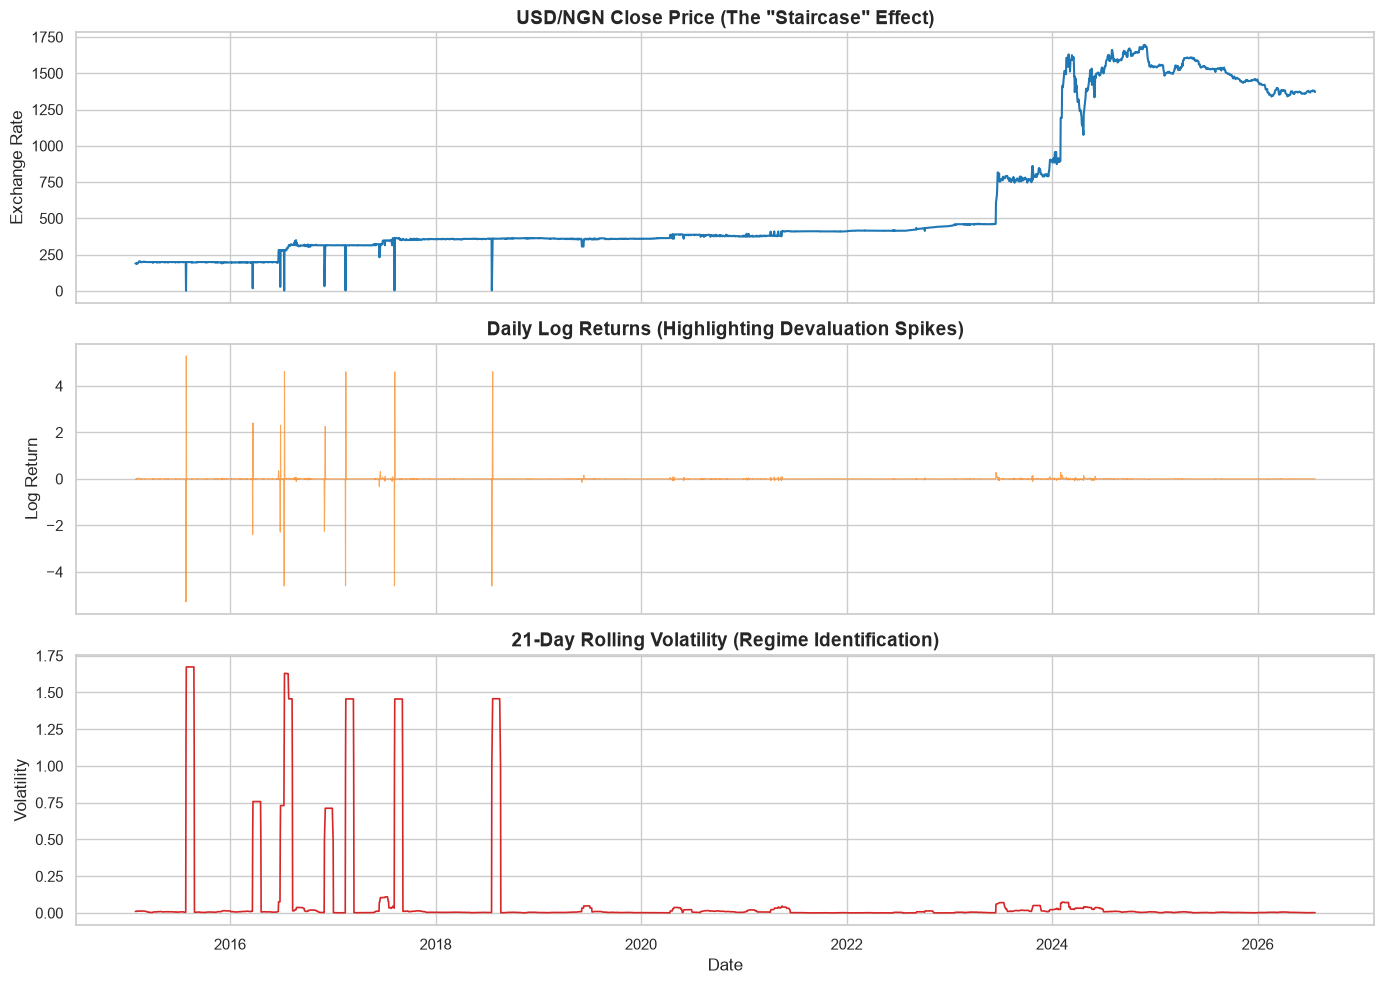

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller


def load_and_prepare_data(filepath="../data/raw/raw_usd_ngn.csv"):
    """Loads the data, handles the index, and calculates returns."""
    df = pd.read_csv(filepath, parse_dates=['Date'], index_col='Date')

    # yfinance sometimes creates multi-level columns; flatten if necessary
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Standardize column name just in case
    df = df[['Close']].dropna()

    # 1. Calculate Log Returns: R_t = ln(P_t / P_{t-1})
    df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

    # 2. Calculate 21-day rolling volatility (approx. 1 business month)
    df['Rolling_Vol'] = df['Log_Returns'].rolling(window=21).std()

    return df.dropna()


def check_stationarity(series):
    """Runs the Augmented Dickey-Fuller test."""
    print("\n🔍 Running Augmented Dickey-Fuller Test...")
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4e}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')

    if result[1] <= 0.05:
        print("Conclusion: Reject the null hypothesis. The series is STATIONARY.")
    else:
        print(
            "Conclusion: Fail to reject the null hypothesis. The series is NON-STATIONARY.")


def plot_market_dynamics(df):
    """Plots price, log returns, and rolling volatility to expose regimes."""
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    sns.set_theme(style="whitegrid")

    # Plot 1: Close Price
    axes[0].plot(df.index, df['Close'], color='tab:blue', linewidth=1.5)
    axes[0].set_title(
        'USD/NGN Close Price (The "Staircase" Effect)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Exchange Rate')

    # Plot 2: Log Returns
    axes[1].plot(df.index, df['Log_Returns'],
                 color='tab:orange', linewidth=0.8, alpha=0.7)
    axes[1].set_title(
        'Daily Log Returns (Highlighting Devaluation Spikes)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Log Return')

    # Plot 3: Rolling Volatility
    axes[2].plot(df.index, df['Rolling_Vol'], color='tab:red', linewidth=1.2)
    axes[2].set_title(
        '21-Day Rolling Volatility (Regime Identification)', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Volatility')
    axes[2].set_xlabel('Date')

    plt.tight_layout()
    plt.savefig('../reports/figures/usd_ngn_eda_plots.png', dpi=300)
    print("\n💾 EDA plots saved to ../reports/figures/usd_ngn_eda_plots.png")
    plt.show()


if __name__ == "__main__":
    # Load and process
    df_processed = load_and_prepare_data()

    # Check stationarity on the raw price vs log returns
    print("--- Raw Close Price Stationarity ---")
    check_stationarity(df_processed['Close'])

    print("\n--- Log Returns Stationarity ---")
    check_stationarity(df_processed['Log_Returns'])

    # Generate the visual profile
    plot_market_dynamics(df_processed)